# Optimizing a stellarator geometry from DESC

This notebook links to DESC directly by default: DESC supplies an installed named equilibrium in memory, and `DescGeometryProvider` evaluates its field line without a geometry file. A saved DESC equilibrium and the committed D-shape fixture remain explicit interoperability/fallback modes.

> Scope: this is a reduced integration example, not a claim of production-ready turbulent transport optimization or end-to-end differentiation through a DESC equilibrium solve.

## Data and optimization flow

`DESC boundary/profile parameters` → `DESC equilibrium solve` → `DescGeometryProvider` → physical field-line and metric arrays → provider-neutral `GeometryResult` → normalized `FluxTubeGeometry` → linear gyrokinetic time evolution → growth rate, frequency, mode structure, and quasilinear proxy → scalar objective → optimizer.

The equilibrium code owns the global magnetic configuration. This package owns the local flux-tube kinetic calculation. The adapter is the contract between them. During one optimization trace, keep `n_z`, velocity and Fourier grids, mode connectivity, selected $k_y$, geometry model, time step, and number of steps fixed. Changing those quantities is remeshing/model selection, not a smooth design-variable update.

In [1]:
from pathlib import Path
import os

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jax_fluxtube_gk import (
    DescGeometryProvider, DesignObjectiveSpec, FourierGridSpec, GeometryRequest,
    OptimizationKnobs, ParallelGridSpec, SingleSurfaceOptimizationConfig,
    VelocityGridSpec, build_desc_geometry_from_arrays, build_fourier_grid,
    assert_fixed_optimization_topology, build_mode_connectivity,
    build_optimization_topology_contract, build_parallel_grid, build_velocity_grid,
    design_objective, internal_geometry_from_result, k_perp_squared, resolve_geometry,
)

jax.config.update("jax_enable_x64", True)

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
FIXTURE = ROOT / "fixtures/desc_geometry_dshape_rho05_alpha0.npz"
GEOMETRY_SOURCE = "provider"  # provider | path | fixture
DESC_CONFIGURATION = "DSHAPE"
DESC_EQUILIBRIUM = os.environ.get("DESC_EQUILIBRIUM")

In [2]:
from desc.grid import LinearGrid


def desc_boundary_xyz(surface, n_theta=60, n_zeta=200):
    """Evaluate a DESC FourierRZToroidalSurface on a (theta, zeta) grid and return
    Cartesian (X, Y, Z) surface grids of shape (n_zeta, n_theta)."""
    grid = LinearGrid(theta=n_theta, zeta=n_zeta, NFP=surface.NFP, endpoint=True)
    data = surface.compute(["X", "Y", "Z"], grid=grid)
    X = data["X"].reshape(grid.num_zeta, grid.num_theta)
    Y = data["Y"].reshape(grid.num_zeta, grid.num_theta)
    Z = data["Z"].reshape(grid.num_zeta, grid.num_theta)
    return X, Y, Z


def plot_boundary_surface(ax, X, Y, Z, **kwargs):
    """Render a stellarator boundary surface with a physically equal-aspect, angled view."""
    ax.plot_surface(X, Y, Z, rstride=1, cstride=1, linewidth=0, antialiased=True, **kwargs)
    span = max(X.max() - X.min(), Y.max() - Y.min(), Z.max() - Z.min())
    ax.set_box_aspect(((X.max() - X.min()) / span, (Y.max() - Y.min()) / span, (Z.max() - Z.min()) / span))
    ax.view_init(elev=35, azim=45)
    ax.set_axis_off()

## Obtain provider-neutral geometry

The default `provider` mode asks the installed DESC library for `DESC_CONFIGURATION` and evaluates the field line in memory. `path` loads a saved DESC equilibrium and then evaluates it through the same provider. `fixture` bypasses DESC and is intended only for reproducibility, CI, or environments without DESC. All modes end at the same internal geometry contract (`B`, parallel streaming factors, drifts, and perpendicular metric coefficients).

In [3]:
request = GeometryRequest(
    configuration=DESC_CONFIGURATION, radial_value=0.5, alpha=0.0,
    n_z=32, z_min=-np.pi, z_max=np.pi, field_periods=1.0,
)

if GEOMETRY_SOURCE == "provider":
    geometry_result = resolve_geometry(
        DescGeometryProvider(revision="record-your-revision"), request
    )
    parallel = geometry_result.parallel_grid
    geometry = internal_geometry_from_result(geometry_result)
    geometry_source = geometry_result.metadata.provenance.source
elif GEOMETRY_SOURCE == "path":
    if not DESC_EQUILIBRIUM:
        raise RuntimeError("Set DESC_EQUILIBRIUM when GEOMETRY_SOURCE='path'")
    geometry_result = resolve_geometry(DescGeometryProvider(path=DESC_EQUILIBRIUM), request)
    parallel = geometry_result.parallel_grid
    geometry = internal_geometry_from_result(geometry_result)
    geometry_source = geometry_result.metadata.provenance.source
elif GEOMETRY_SOURCE == "fixture":
    fixture = np.load(FIXTURE)
    z = np.asarray(fixture["z"], dtype=float)
    dz = z[1] - z[0]
    parallel = build_parallel_grid(
        ParallelGridSpec(n_z=len(z), z_min=float(z[0]), z_max=float(z[-1] + dz))
    )
    geometry = build_desc_geometry_from_arrays(
        parallel, **{name: fixture[name] for name in (
            "theta", "phi", "alpha", "rho", "B", "b_dot_grad_z",
            "grad_psi_sq", "grad_alpha_sq", "grad_psi_dot_grad_alpha",
            "B_cross_gradB_dot_grad_psi", "B_cross_gradB_dot_grad_alpha",
            "b_cross_kappa_dot_grad_psi", "b_cross_kappa_dot_grad_alpha",
        )}
    )
    geometry_source = str(FIXTURE)
else:
    raise ValueError("GEOMETRY_SOURCE must be 'provider', 'path', or 'fixture'")

print(f"geometry source: {geometry_source}")
print(f"parallel points: {parallel.z.size}; normalized geometry fields: B, F, G, drifts, metric")

geometry source: installed DESC named configuration DSHAPE

parallel points: 32; normalized geometry fields: B, F, G, drifts, metric

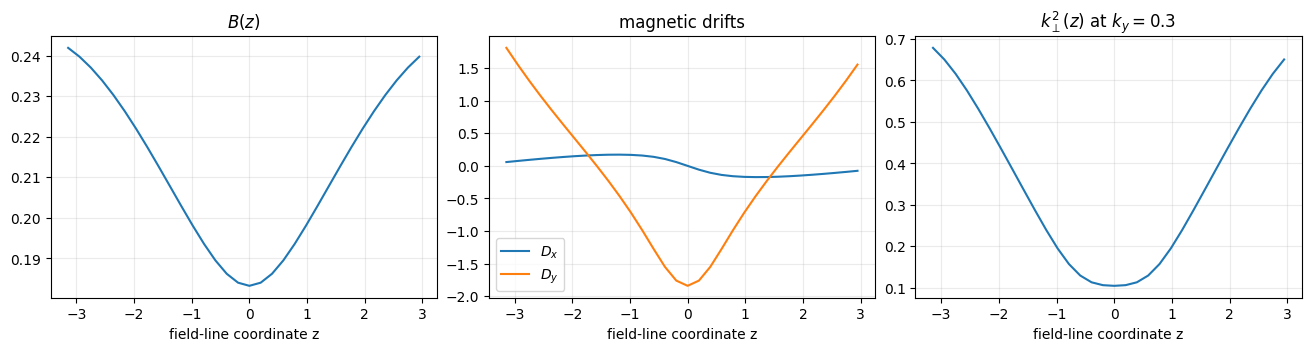

In [4]:
fourier_for_plot = build_fourier_grid(
    FourierGridSpec(n_kx=1, n_ky=1, kx_max=0.0, ky_values=(0.3,))
)
kp2 = np.asarray(k_perp_squared(geometry, fourier_for_plot)).squeeze()
z = np.asarray(parallel.z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), constrained_layout=True)
axes[0].plot(z, np.asarray(geometry.B))
axes[0].set_title(r"$B(z)$")
axes[1].plot(z, np.asarray(geometry.D_x), label=r"$D_x$")
axes[1].plot(z, np.asarray(geometry.D_y), label=r"$D_y$")
axes[1].legend()
axes[1].set_title("magnetic drifts")
axes[2].plot(z, kp2)
axes[2].set_title(r"$k_\perp^2(z)$ at $k_y=0.3$")
for ax in axes:
    ax.set_xlabel("field-line coordinate z")
    ax.grid(alpha=0.25)
plt.show()

## What the gyrokinetic objective does

The code builds velocity, parallel, and perpendicular Fourier grids; evolves a small complex distribution perturbation with the linear gyrokinetic residual; solves the field response; and extracts a selected-mode growth rate and frequency. `DesignObjectiveSpec` combines those with optional mode-shape and quasilinear penalties. The tiny grid and two time steps below are for tracing the software path only—not converged physics.

In [5]:
velocity = build_velocity_grid(VelocityGridSpec(n_vpar=2, n_mu=2, vpar_max=1.5, mu_max=1.0))
fourier = build_fourier_grid(FourierGridSpec(n_kx=1, n_ky=1, kx_max=0.0, ky_values=(0.3,)))
connectivity = build_mode_connectivity(fourier)
shape = (velocity.vpar.size, velocity.mu.size, parallel.z.size, 1, 1)
index = jnp.arange(np.prod(shape), dtype=jnp.float64).reshape(shape)
initial_state = 1e-2 * (jnp.cos(index / 7.0) + 1j * jnp.sin(index / 11.0))
spec = DesignObjectiveSpec(selected_ky=0, growth_weight=1.0)
config = SingleSurfaceOptimizationConfig(
    geometry_model="precomputed", dt=0.005, n_steps=2, selected_ky=0,
    objective_kind="selected_growth", store_history=False,
)

def fixed_geometry_objective(temperature_gradient):
    result = design_objective(
        OptimizationKnobs(density_gradient=0.8, temperature_gradient=temperature_gradient),
        velocity, parallel, fourier, initial_state, spec, connectivity=connectivity,
        config=config, geometry=geometry,
    )
    return result.scalar_objective, result

(value, result), gradient = jax.value_and_grad(fixed_geometry_objective, has_aux=True)(jnp.array(2.1))
print(f"objective={float(value): .6e}")
print(f"growth={float(result.selected_growth_rate): .6e}, frequency={float(result.selected_frequency): .6e}")
print(f"d objective / d(R/L_T)={float(gradient): .6e}")

objective= 1.529099e-01

growth= 1.529099e-01, frequency=-9.177167e-02

d objective / d(R/L_T)=-2.952268e-07

## Shape optimization: two valid architectures

1. **Outer loop (available now):** change DESC boundary coefficients, solve a fresh equilibrium, request geometry again, evaluate the GK objective, and estimate derivatives by finite differences or use a derivative-free optimizer. This is robust but expensive.
2. **End-to-end AD (future integration work):** keep the equilibrium solve, field-line extraction, normalization, and GK solve in one JAX trace. An in-memory provider may advertise differentiability, but setting `differentiable=True` is metadata—not proof that every DESC operation is traceable. Audit every gradient against finite differences and monitor eigenmode branch changes.

The next loop is executable but is deliberately a **geometry surrogate**: the scalar controls cosine-$B$ amplitude, not a DESC boundary harmonic. It illustrates the optimizer/provider/GK separation without pretending to run DESC.

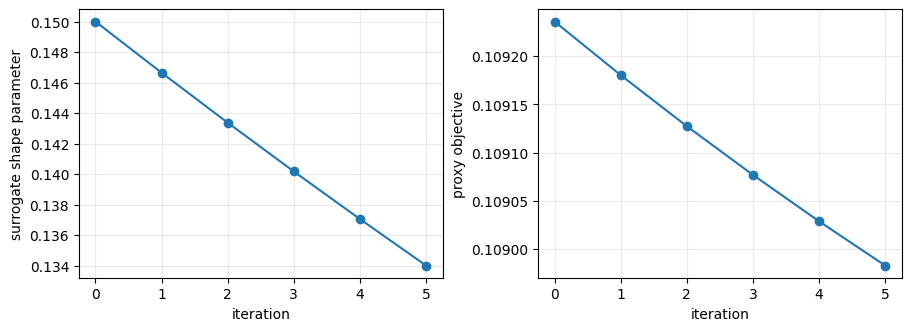

In [6]:
from jax_fluxtube_gk import SyntheticGeometryProvider

def surrogate_shape_cost(amplitude):
    surrogate_result = resolve_geometry(SyntheticGeometryProvider(magnetic_field_amplitude=amplitude), request)
    surrogate_geometry = internal_geometry_from_result(surrogate_result)
    # Cheap proxy used only to visualize the outer loop; replace this line with design_objective(...).
    return float(jnp.mean(k_perp_squared(surrogate_geometry, fourier_for_plot) / surrogate_geometry.B[:, None, None]))

parameter, fd_step, learning_rate = 0.15, 1e-3, 0.2
history = []
for iteration in range(6):
    cost = surrogate_shape_cost(parameter)
    grad = (surrogate_shape_cost(parameter + fd_step) - surrogate_shape_cost(parameter - fd_step)) / (2 * fd_step)
    history.append((iteration, parameter, cost, grad))
    parameter = float(np.clip(parameter - learning_rate * grad, 0.0, 0.4))
history = np.asarray(history)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)
axes[0].plot(history[:, 0], history[:, 1], "o-")
axes[0].set_ylabel("surrogate shape parameter")
axes[1].plot(history[:, 0], history[:, 2], "o-")
axes[1].set_ylabel("proxy objective")
for ax in axes:
    ax.set_xlabel("iteration")
    ax.grid(alpha=0.25)
plt.show()

iteration 0: scale=1.000000 objective= 1.529099e-01 sensitivity=-4.138e-03

iteration 1: scale=1.000083 objective= 1.529096e-01 sensitivity=-4.134e-03

iteration 2: scale=1.000165 objective= 1.529094e-01 sensitivity=-4.121e-03

iteration 3: scale=1.000248 objective= 1.529090e-01 sensitivity=-4.133e-03

iteration 4: scale=1.000331 objective= 1.529087e-01 sensitivity=-4.135e-03

saved /Users/mohsensadr/Codes/GitHub/fusion/JAXFluxTubeGK/figures/desc_boundary_evolution.png

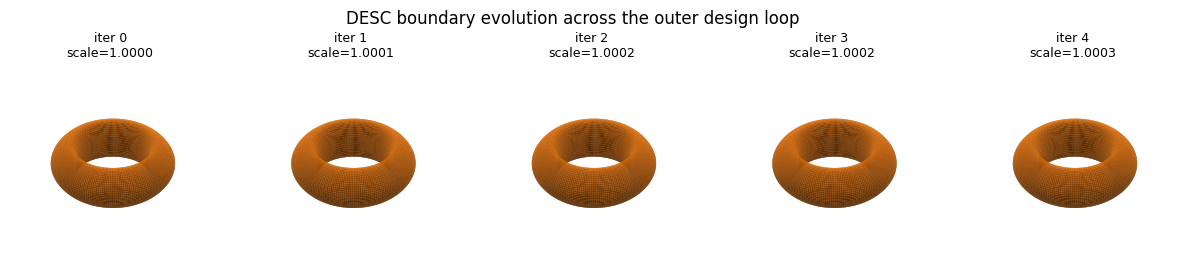

saved /Users/mohsensadr/Codes/GitHub/fusion/JAXFluxTubeGK/figures/desc_initial_live_design_scan.png

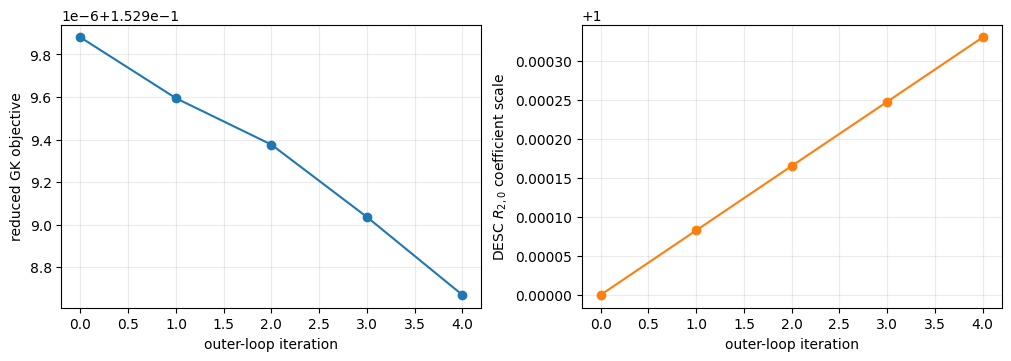

[{'scale': 1.0, 'coefficient': 0.106, 'objective': 0.1529098802361517, 'growth_rate': 0.1529098802361517, 'frequency': -0.0917717648233584, 'equilibrium_success': True, 'provider': 'desc', 'iteration': 0, 'requested_scale': 1.0, 'sensitivity': -0.0041381553339547815}, {'scale': 1.000082763106679, 'coefficient': 0.10600877288930798, 'objective': 0.1529095943533676, 'growth_rate': 0.1529095943533676, 'frequency': -0.09176340365314861, 'equilibrium_success': True, 'provider': 'desc', 'iteration': 1, 'requested_scale': 1.000082763106679, 'sensitivity': -0.004133766856204789}, {'scale': 1.0001654384438032, 'coefficient': 0.10601753647504314, 'objective': 0.15290937631284862, 'growth_rate': 0.15290937631284862, 'frequency': -0.0917527214773337, 'equilibrium_success': True, 'provider': 'desc', 'iteration': 2, 'requested_scale': 1.0001654384438032, 'sensitivity': -0.004121368592630579}, {'scale': 1.000247865815656, 'coefficient': 0.10602627377645953, 'objective': 0.15290903645786003, 'growth_r

In [7]:
reference_topology = build_optimization_topology_contract(
    velocity, parallel, fourier, connectivity=connectivity,
    geometry_metadata=geometry_result.metadata if GEOMETRY_SOURCE != "fixture" else None,
)

def evaluate_live_desc_design(boundary_scale, m=2, n=0, maxiter=50):
    """Scale one DESC R-boundary harmonic, re-solve, and evaluate GK."""
    from desc.examples import get as get_desc_example

    equilibrium = get_desc_example(DESC_CONFIGURATION).copy()
    surface = equilibrium.surface.copy()
    coefficient_index = surface.R_basis.get_idx(M=m, N=n)
    coefficients = np.array(surface.R_lmn, copy=True)
    reference_coefficient = float(coefficients[coefficient_index])
    coefficients[coefficient_index] = boundary_scale * reference_coefficient
    surface.R_lmn = coefficients
    equilibrium.surface = surface
    equilibrium, solve_status = equilibrium.solve(
        copy=False, verbose=0, maxiter=maxiter
    )
    candidate_result = resolve_geometry(
        DescGeometryProvider(equilibrium=equilibrium, differentiable=False), request
    )
    candidate_geometry = internal_geometry_from_result(candidate_result)
    candidate_topology = build_optimization_topology_contract(
        velocity, candidate_result.parallel_grid, fourier, connectivity=connectivity,
        geometry_metadata=candidate_result.metadata,
    )
    assert_fixed_optimization_topology(reference_topology, candidate_topology)
    objective = design_objective(
        OptimizationKnobs(density_gradient=0.8, temperature_gradient=2.1),
        velocity, candidate_result.parallel_grid, fourier, initial_state, spec,
        connectivity=connectivity, config=config, geometry=candidate_geometry,
    )
    return {
        "scale": float(boundary_scale),
        "coefficient": float(coefficients[coefficient_index]),
        "objective": float(objective.scalar_objective),
        "growth_rate": float(objective.selected_growth_rate),
        "frequency": float(objective.selected_frequency),
        "equilibrium_success": bool(getattr(solve_status, "success", True)),
        "provider": candidate_result.metadata.provenance.provider,
        "surface": equilibrium.surface,
    }

if GEOMETRY_SOURCE == "provider":
    # Outer-loop hill-climb: at each iteration, take a real 3-point central-difference
    # sensitivity through fresh DESC solves (as above), step the boundary scale, and
    # record the resulting real 3D boundary shape. This is still a reduced,
    # single-harmonic outer loop -- not a claim of unrestricted shape optimization.
    N_ITERATIONS = 5
    relative_step = 0.01
    learning_rate = 0.02
    scale_bounds = (0.95, 1.05)
    scale = 1.0
    history = []
    boundary_frames = []
    for iteration in range(N_ITERATIONS):
        design_scales = scale + scale * np.array([-relative_step, 0.0, relative_step])
        live_design = [evaluate_live_desc_design(s) for s in design_scales]
        objectives = np.array([row["objective"] for row in live_design])
        sensitivity = float(
            (objectives[2] - objectives[0]) / (design_scales[2] - design_scales[0])
        )
        center = live_design[1]
        history.append(
            {key: value for key, value in center.items() if key != "surface"}
            | {"iteration": iteration, "requested_scale": scale, "sensitivity": sensitivity}
        )
        boundary_frames.append((iteration, scale, desc_boundary_xyz(center["surface"])))
        print(
            f"iteration {iteration}: scale={scale:.6f} objective={center['objective']: .6e} "
            f"sensitivity={sensitivity: .3e}"
        )
        scale = float(np.clip(scale - learning_rate * sensitivity, *scale_bounds))

    fig = plt.figure(figsize=(3.0 * N_ITERATIONS, 3.2))
    for column, (iteration, iter_scale, (X, Y, Z)) in enumerate(boundary_frames):
        ax = fig.add_subplot(1, N_ITERATIONS, column + 1, projection="3d")
        plot_boundary_surface(ax, X, Y, Z, color="tab:orange", alpha=0.95)
        ax.set_title(f"iter {iteration}\nscale={iter_scale:.4f}", fontsize=9)
    fig.suptitle("DESC boundary evolution across the outer design loop")
    boundary_figure_path = ROOT / "figures/desc_boundary_evolution.png"
    fig.savefig(boundary_figure_path, dpi=150, bbox_inches="tight")
    print(f"saved {boundary_figure_path}")
    plt.show()

    iterations = np.array([row["iteration"] for row in history])
    scales = np.array([row["scale"] for row in history])
    objectives = np.array([row["objective"] for row in history])
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
    axes[0].plot(iterations, objectives, "o-")
    axes[0].set_ylabel("reduced GK objective")
    axes[1].plot(iterations, scales, "o-", color="tab:orange")
    axes[1].set_ylabel(r"DESC $R_{2,0}$ coefficient scale")
    for ax in axes:
        ax.set_xlabel("outer-loop iteration")
        ax.grid(alpha=0.25)
    figure_path = ROOT / "figures/desc_initial_live_design_scan.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    print(f"saved {figure_path}")
    plt.show()
    print(history)
else:
    print("Select GEOMETRY_SOURCE='provider' to run the live DESC design scan.")

### Practical next step

Begin with 1–3 symmetry-preserving DESC boundary harmonics and an outer finite-difference loop. Cache equilibrium/geometry evaluations outside the repository, record provider revision and normalization metadata, reject topology changes, include MHD/engineering constraints, and validate each accepted design at higher kinetic resolution. Only move to end-to-end AD after the outer loop and gradient audits agree.

![Initial live DESC design sensitivity](../figures/desc_initial_live_design_scan.png)

The real 3D boundary below is evaluated directly from the solved DESC equilibrium's boundary surface at each outer-loop iteration.

![DESC boundary evolution across the outer design loop](../figures/desc_boundary_evolution.png)